<a href="https://colab.research.google.com/github/sandyy221/244107020029_PemMes/blob/main/1790748288557_DBSCAN_EUCLIDIAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Setup Awal

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

1. Data Understanding

1.1 Load Dataset

In [ ]:
df = pd.read_csv('burnout_dataset1.csv')

df.head()

print(f'Jumlah data  : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')

Jumlah data  : 50000
Jumlah kolom : 40


1.2 Data Preview

In [ ]:
print("5 Baris Pertama Dataset:")
display(df.head())

print("\nNama Semua Kolom:")
print(df.columns.tolist())

5 Baris Pertama Dataset:


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low



Nama Semua Kolom:
['Person_ID', 'Age', 'Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']


1.3 Tipe data dan Missing Values

In [ ]:
print('Tipe Data:')
print(df.dtypes)

print('\nJumlah Missing Value:')
missing = df.isnull().sum()

missing[missing > 0]

Tipe Data:
Person_ID                          int64
Age                              float64
Gender                            object
Country                           object
Occupation                        object
Education_Level                   object
Employment_Status                 object
Monthly_Income_USD               float64
Work_Hours_Per_Week                int64
Remote_Work                       object
Job_Satisfaction                 float64
Work_Life_Balance                float64
Sleep_Hours                      float64
Sleep_Quality                     object
Stress_Level                      object
Anxiety_Score                    float64
Depression_Score                 float64
Mood_Score                       float64
Emotional_Stability                int64
Physical_Activity_Hours          float64
Exercise_Frequency                object
Meditation_Minutes               float64
Screen_Time_Hours                float64
Social_Media_Hours               float64
Gamin

,0
Age,250
Monthly_Income_USD,1450
Job_Satisfaction,500
Work_Life_Balance,650
Sleep_Hours,950
Anxiety_Score,800
Depression_Score,850
Mood_Score,900
Physical_Activity_Hours,1100
Meditation_Minutes,1200


1.4 Identifikasi Kolom yang Digunakan

In [ ]:
# Kolom numerik asli
numeric_columns = df.select_dtypes(include='number').columns

# Menghapus identifier
numeric_columns = numeric_columns.drop(
    ['Person_ID'],
    errors='ignore'
)

# Kolom kategorikal yang akan di-encoding
categorical_columns = [
    'Remote_Work',
    'Sleep_Quality',
    'Stress_Level',
    'Exercise_Frequency',
    'Alcohol_Consumption',
    'Smoking',
    'Healthy_Diet',
    'Chronic_Stress',
    'Family_History_Mental_Illness',
    'Therapy_Attendance',
    'Support_System',
    'Mental_Health_Status'
]

print('Kolom Numerik:')
print(numeric_columns.tolist())

print('\nKolom Kategorikal yang akan di-encoding:')
print(categorical_columns)

Kolom Numerik:
['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']

Kolom Kategorikal yang akan di-encoding:
['Remote_Work', 'Sleep_Quality', 'Stress_Level', 'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Mental_Health_Status']


1.5 Statistik Deskriptif

In [ ]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,49750.0,41.448181,13.871634,18.0,29.0,41.0,53.0,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.0,6231.0,9134.0,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.0,45.0,58.0,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.0,6.0,8.0,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.0,6.0,8.0,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.5,7.0,8.5,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.0,39.0,59.0,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.0,39.0,60.0,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.0,61.0,80.0,100.0
Emotional_Stability,50000.0,59.382100,26.090946,0.0,40.0,60.0,81.0,100.0


1.6 Visualisasi Distribusi Data

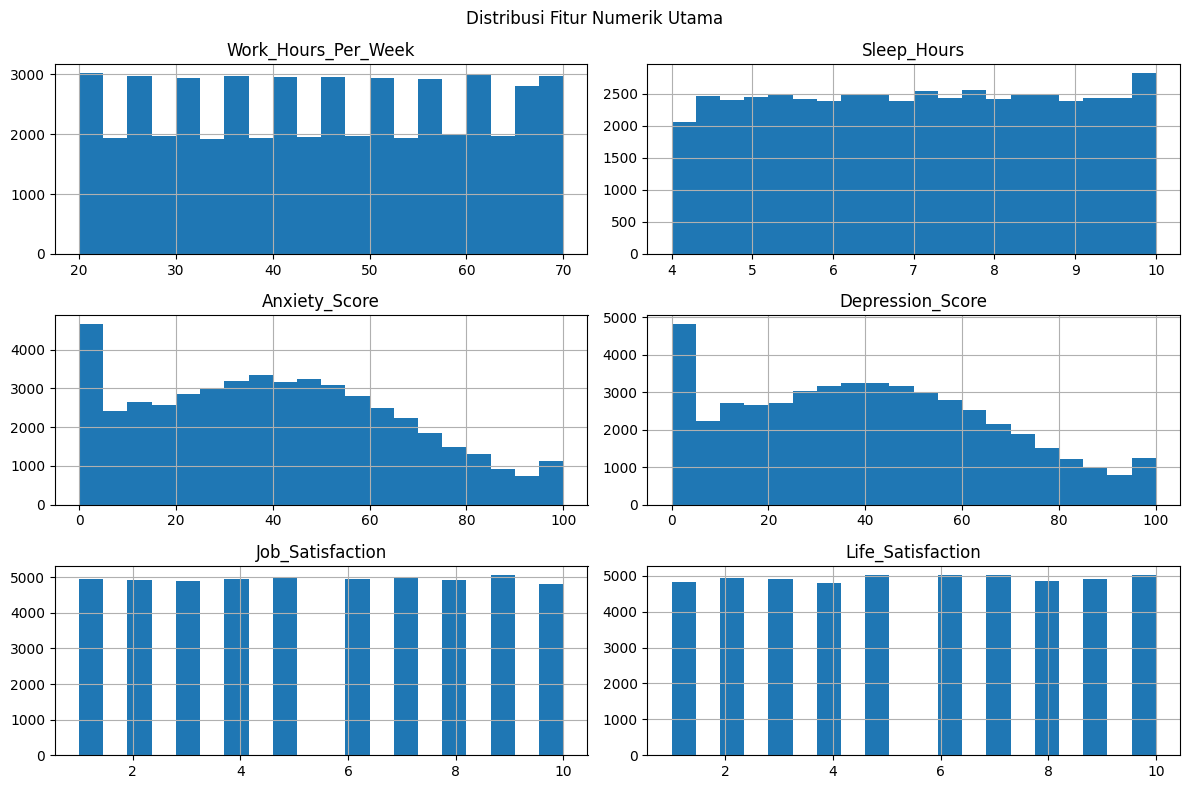

In [ ]:
selected_features = [
    'Work_Hours_Per_Week',
    'Sleep_Hours',
    'Anxiety_Score',
    'Depression_Score',
    'Job_Satisfaction',
    'Life_Satisfaction'
]

df[selected_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribusi Fitur Numerik Utama')
plt.tight_layout()
plt.show()

1.7 Visualisasi Deteksi Outlier

In [ ]:
numeric_columns = df.select_dtypes(include='number').columns

numeric_columns = numeric_columns.drop(
    ['person_id', 'Person_ID'],
    errors='ignore'
)

numeric_data = df[numeric_columns]

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (numeric_data < lower_bound) |
    (numeric_data > upper_bound)
)

In [ ]:
outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outlier_mask.sum(),
    'Persentase (%)': (
        outlier_mask.sum() / len(df) * 100
    ).round(2)
})

outlier_summary = outlier_summary.sort_values(
    'Jumlah Outlier',
    ascending=False
)

outlier_summary

,Jumlah Outlier,Persentase (%)
Age,0,0.0
Monthly_Income_USD,0,0.0
Work_Hours_Per_Week,0,0.0
Job_Satisfaction,0,0.0
Work_Life_Balance,0,0.0
Sleep_Hours,0,0.0
Anxiety_Score,0,0.0
Depression_Score,0,0.0
Mood_Score,0,0.0
Emotional_Stability,0,0.0


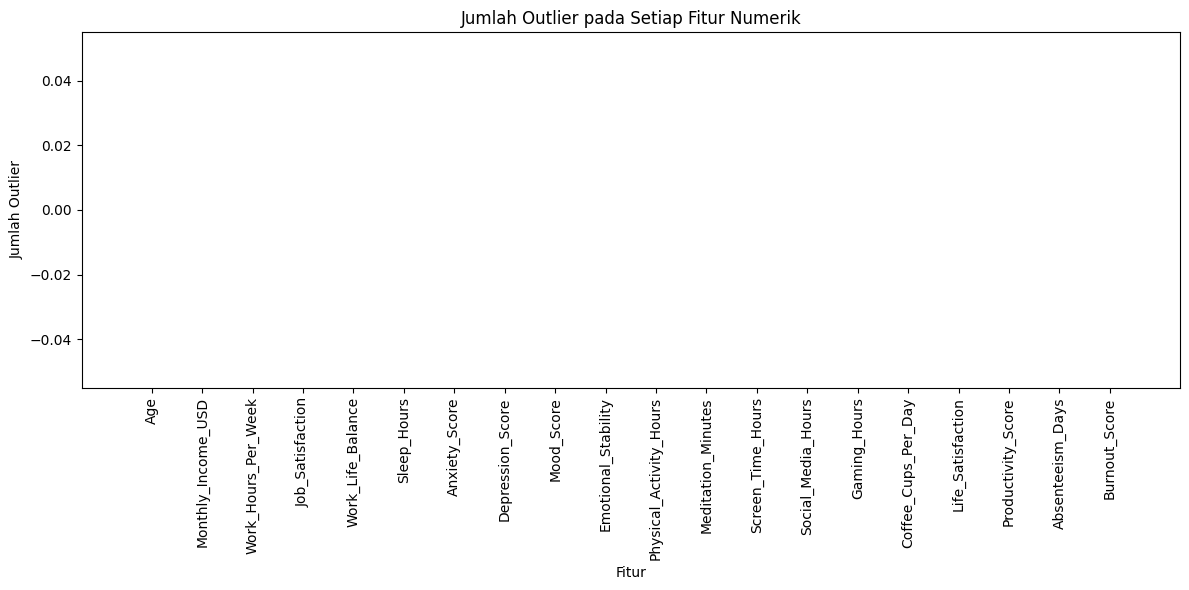

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    outlier_summary.index,
    outlier_summary['Jumlah Outlier']
)

plt.title('Jumlah Outlier pada Setiap Fitur Numerik')
plt.xlabel('Fitur')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
print(outlier_summary)

                         Jumlah Outlier  Persentase (%)
Age                                   0             0.0
Monthly_Income_USD                    0             0.0
Work_Hours_Per_Week                   0             0.0
Job_Satisfaction                      0             0.0
Work_Life_Balance                     0             0.0
Sleep_Hours                           0             0.0
Anxiety_Score                         0             0.0
Depression_Score                      0             0.0
Mood_Score                            0             0.0
Emotional_Stability                   0             0.0
Physical_Activity_Hours               0             0.0
Meditation_Minutes                    0             0.0
Screen_Time_Hours                     0             0.0
Social_Media_Hours                    0             0.0
Gaming_Hours                          0             0.0
Coffee_Cups_Per_Day                   0             0.0
Life_Satisfaction                     0         

2.1 Seleksi Kolom

In [ ]:
selected_columns = list(numeric_columns) + categorical_columns

X = df[selected_columns].copy()

X.head()

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,58.0,2786.0,67,3.0,7.0,4.6,74.0,75.0,26.0,18,...,High,Weekly,Yes,Yes,No,Yes,No,Yes,Average,Critical
1,24.0,8027.0,44,5.0,8.0,4.7,58.0,80.0,29.0,37,...,Moderate,Weekly,Yes,Yes,Yes,No,Yes,No,Good,Critical
2,59.0,3177.0,60,8.0,7.0,6.3,54.0,55.0,44.0,48,...,Moderate,Daily,Yes,No,No,No,Yes,No,Average,Needs Attention
3,65.0,4093.0,25,2.0,9.0,7.1,12.0,11.0,88.0,80,...,Low,Weekly,Yes,No,No,No,No,Yes,Good,Healthy
4,64.0,NaN,52,1.0,4.0,9.1,25.0,48.0,67.0,76,...,Low,Never,Yes,No,No,No,Yes,No,Poor,Healthy


2.2 Encoding Data Kategorikal

In [ ]:
encoding_maps = {
    'Remote_Work': {
        'No': 0,
        'Hybrid': 1,
        'Yes': 2
    },

    'Sleep_Quality': {
        'Excellent': 0,
        'Good': 1,
        'Average': 2,
        'Poor': 3
    },

    'Stress_Level': {
        'Low': 0,
        'Moderate': 1,
        'High': 2
    },

    'Exercise_Frequency': {
        'Daily': 0,
        'Weekly': 1,
        'Rarely': 2,
        'Never': 3
    },

    'Alcohol_Consumption': {
        'No': 0,
        'Yes': 1
    },

    'Smoking': {
        'No': 0,
        'Yes': 1
    },

    'Healthy_Diet': {
        'No': 0,
        'Yes': 1
    },

    'Chronic_Stress': {
        'No': 0,
        'Yes': 1
    },

    'Family_History_Mental_Illness': {
        'No': 0,
        'Yes': 1
    },

    'Therapy_Attendance': {
        'No': 0,
        'Yes': 1
    },

    'Support_System': {
        'Poor': 0,
        'Average': 1,
        'Good': 2,
        'Excellent': 3
    },

    'Mental_Health_Status': {
        'Healthy': 0,
        'Needs Attention': 1,
        'Critical': 2
    }
}

for column, mapping in encoding_maps.items():
    X[column] = X[column].map(mapping)

X[categorical_columns].head()

,Remote_Work,Sleep_Quality,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1,3,2,1,1,1,0,1,0,1.0,1,2
1,1,3,1,1,1,1,1,0,1,0.0,2,2
2,0,2,1,0,1,0,0,0,1,0.0,1,1
3,2,1,0,1,1,0,0,0,0,1.0,2,0
4,0,0,0,3,1,0,0,0,1,0.0,0,0


2.3 Penanganan Missing Values

In [ ]:
print('Missing value sebelum preprocessing:')
print(X.isnull().sum())

X = X.fillna(X.median())

print(
    '\nJumlah missing value setelah preprocessing:',
    X.isnull().sum().sum()
)

Missing value sebelum preprocessing:
Age                               250
Monthly_Income_USD               1450
Work_Hours_Per_Week                 0
Job_Satisfaction                  500
Work_Life_Balance                 650
Sleep_Hours                       950
Anxiety_Score                     800
Depression_Score                  850
Mood_Score                        900
Emotional_Stability                 0
Physical_Activity_Hours          1100
Meditation_Minutes               1200
Screen_Time_Hours                 850
Social_Media_Hours                600
Gaming_Hours                      750
Coffee_Cups_Per_Day                 0
Life_Satisfaction                 700
Productivity_Score                950
Absenteeism_Days                    0
Burnout_Score                       0
Remote_Work                         0
Sleep_Quality                       0
Stress_Level                        0
Exercise_Frequency                  0
Alcohol_Consumption                 0
Smoking      

2.4 Penanganan Outlier

In [ ]:
# Karena tidak, tidak dilakukan

2.5 Standardisasi

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196378,-1.059170,1.497320,-0.877799,0.522638,-1.400203,1.301535,1.319769,-1.316899,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,-0.996685,2.53389,-0.996765,1.016577,-0.441976,1.633584
1,-1.260836,0.543024,-0.064238,-0.176698,0.873599,-1.341801,0.681279,1.511451,-1.199485,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,1.003326,-0.39465,1.003245,-0.983693,0.452894,1.633584
2,1.268649,-0.939640,1.022063,0.874952,0.522638,-0.407356,0.526215,0.553042,-0.612419,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-0.441976,0.373764
3,1.702275,-0.659615,-1.354221,-1.228349,1.224560,0.059866,-1.101957,-1.133757,1.109642,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,-0.996685,-0.39465,-0.996765,1.016577,0.452894,-0.886057
4,1.630004,-0.006020,0.478912,-1.578899,-0.530247,1.227922,-0.597999,0.284688,0.287749,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-1.336847,-0.886057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.393584,-0.828669,-0.132132,0.874952,0.171676,0.001464,0.642513,0.323024,-0.573281,-0.551235,...,0.411952,-0.455507,1.008436,-0.996327,1.003326,-0.39465,1.003245,-0.983693,-0.441976,0.373764
49996,1.124107,1.338771,-1.422115,-1.228349,0.171676,-1.575412,-1.334553,-1.555457,1.305331,1.556797,...,-1.014673,-1.351150,1.008436,1.003687,-0.996685,-0.39465,-0.996765,1.016577,1.347764,-0.886057
49997,-0.538126,-0.950034,0.750488,0.874952,-1.232169,0.351880,0.952641,1.434779,-1.042934,-1.011169,...,0.411952,1.335781,1.008436,-0.996327,1.003326,-0.39465,-0.996765,1.016577,-1.336847,1.633584
49998,1.413191,-0.754995,-1.082646,-0.176698,0.522638,0.001464,-0.326637,-0.903739,0.561714,0.100338,...,-1.014673,1.335781,1.008436,1.003687,-0.996685,-0.39465,-0.996765,1.016577,-1.336847,-0.886057


2.6 Data Bersih

In [ ]:
print('Dimensi data setelah preprocessing:', X.shape)
print('Jumlah missing value:', X.isnull().sum().sum())

X_scaled.head()

Dimensi data setelah preprocessing: (50000, 32)
Jumlah missing value: 0


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196378,-1.059170,1.497320,-0.877799,0.522638,-1.400203,1.301535,1.319769,-1.316899,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,-0.996685,2.53389,-0.996765,1.016577,-0.441976,1.633584
1,-1.260836,0.543024,-0.064238,-0.176698,0.873599,-1.341801,0.681279,1.511451,-1.199485,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,1.003326,-0.39465,1.003245,-0.983693,0.452894,1.633584
2,1.268649,-0.939640,1.022063,0.874952,0.522638,-0.407356,0.526215,0.553042,-0.612419,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-0.441976,0.373764
3,1.702275,-0.659615,-1.354221,-1.228349,1.224560,0.059866,-1.101957,-1.133757,1.109642,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,-0.996685,-0.39465,-0.996765,1.016577,0.452894,-0.886057
4,1.630004,-0.006020,0.478912,-1.578899,-0.530247,1.227922,-0.597999,0.284688,0.287749,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-1.336847,-0.886057


3. Reduksi Dimensi PCA

3.1 Reduksi Dimensi

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Jalankan DBSCAN Euclidean langsung pada data 2D PCA
db_pca = DBSCAN(eps=0.1, min_samples=4, metric="euclidean", n_jobs=-1)
clusters_pca = db_pca.fit_predict(X_pca)

print(
    "Jumlah klaster terbentuk di ruang PCA:",
    len(set(clusters_pca)) - (1 if -1 in clusters_pca else 0),
)

Jumlah klaster terbentuk di ruang PCA: 6


3.2 Visualisasi Hasil Klaster

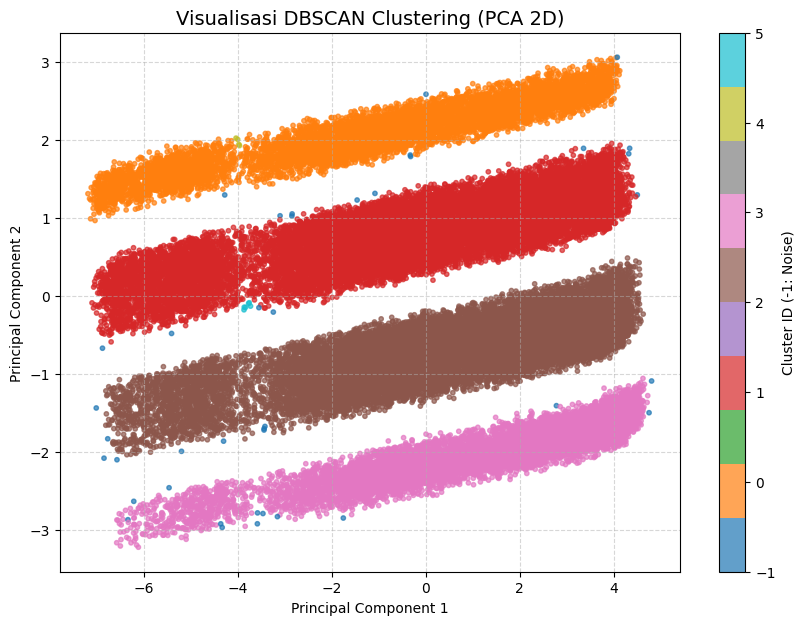

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, label='Cluster ID (-1: Noise)')
plt.title('Visualisasi DBSCAN Clustering (PCA 2D)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

4. Modeling

4.1 Penentuan Parameter eps

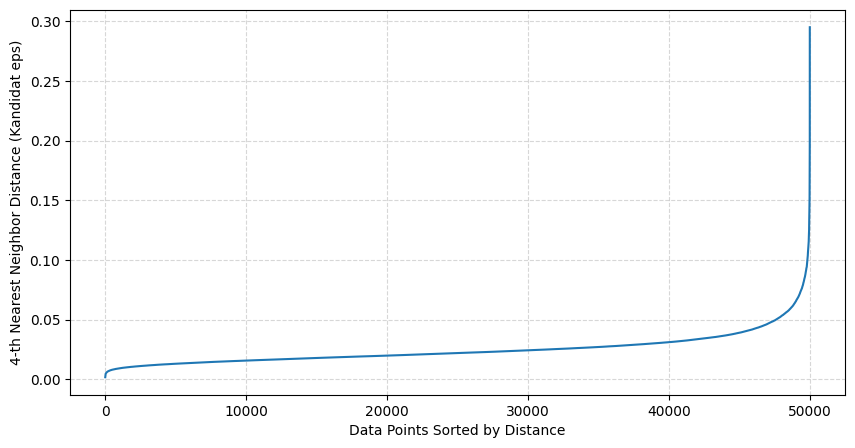

In [ ]:
k = 4
nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
nn_fit = nn.fit(X_pca)
distances, indices = nn_fit.kneighbors(X_pca)

distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{k}-th Nearest Neighbor Distance (Kandidat eps)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

4.2 Eksperimen min_samples & Training DBSCAN euclidian

In [ ]:
param_experiments = [
    {'eps': 4.1, 'min_samples': 32},
    {'eps': 4.2, 'min_samples': 32},
    {'eps': 4.2, 'min_samples': 48},
    {'eps': 4.2, 'min_samples': 64},
    {'eps': 4.3, 'min_samples': 64},
]

print(f"{'eps':<6} | {'min_samples':<12} | {'Klaster':<8} | {'Noise (%)':<10}")
print("-" * 45)

for p in param_experiments:

    db = DBSCAN(eps=p['eps'], min_samples=p['min_samples'], metric='euclidean', n_jobs=-1)
    labels = db.fit_predict(X_scaled)


    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)


    noise_pct = (labels == -1).sum() / len(labels) * 100


    print(f"{p['eps']:<6.1f} | {p['min_samples']:<12} | {n_clusters:<8} | {noise_pct:<10.2f}%")

eps    | min_samples  | Klaster  | Noise (%) 
---------------------------------------------
4.1    | 32           | 2        | 31.38     %
4.2    | 32           | 2        | 12.67     %
4.2    | 48           | 2        | 27.06     %
4.2    | 64           | 4        | 41.87     %
4.3    | 64           | 2        | 18.26     %


In [ ]:
# 3.3 Training DBSCAN Euclidean

best_eps = 4.3
best_min_samples = 64

dbscan_model = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric='euclidean',
    n_jobs=-1
)

# Training dan pembuatan label
clusters = dbscan_model.fit_predict(X_scaled)

print("Hasil Pembagian Klaster:")
print(pd.Series(clusters).value_counts())

Hasil Pembagian Klaster:
 0    37867
-1     9129
 1     3004
Name: count, dtype: int64


5. Evaluasi

5.1 Jumlah Cluster dan Noise dan Distribusi Cluster

In [ ]:
labels = dbscan_model.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print("Jumlah Klaster :", n_clusters)
print(f"Jumlah Noise   : {n_noise} ({n_noise / len(labels) * 100:.2f}%)")

Jumlah Klaster : 2
Jumlah Noise   : 9129 (18.26%)


Distribusi Anggota Klaster:
-1     9129
 0    37867
 1     3004
Name: count, dtype: int64


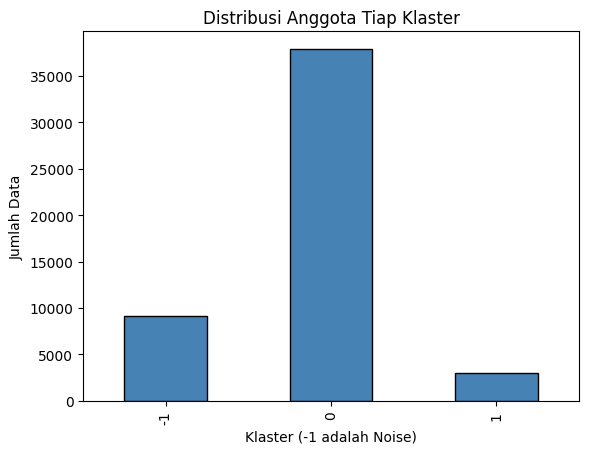

In [ ]:
#distribusi

distribusi = pd.Series(labels).value_counts().sort_index()
print("Distribusi Anggota Klaster:")
print(distribusi)

# Visualisasi diagram batang sederhana
distribusi.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribusi Anggota Tiap Klaster")
plt.xlabel("Klaster (-1 adalah Noise)")
plt.ylabel("Jumlah Data")
plt.show()

In [ ]:
import time

mem_penuh = X_scaled.memory_usage(deep=True).sum() / 1024**2
hasil_efisiensi = []

for frac in [0.2, 0.4, 0.6, 0.8, 1.0]:
    data = X_scaled.sample(frac=frac, random_state=42)
    mem = data.memory_usage(deep=True).sum() / 1024**2

    start = time.perf_counter()
    lbl = DBSCAN(eps=best_eps, min_samples=best_min_samples,
                 metric='euclidean', n_jobs=-1).fit_predict(data)
    waktu = time.perf_counter() - start

    hasil_efisiensi.append({
        'Data (%)': int(frac * 100),
        'Jumlah Data': len(data),
        'Klaster': len(set(lbl)) - (1 if -1 in lbl else 0),
        'Noise (%)': round((lbl == -1).mean() * 100, 2),
        'Runtime (s)': round(waktu, 2),
        'Memori (MB)': round(mem, 2),
        'Memori Dihemat (MB)': round(mem_penuh - mem, 2)
    })

pd.DataFrame(hasil_efisiensi)

,Data (%),Jumlah Data,Klaster,Noise (%),Runtime (s),Memori (MB),Memori Dihemat (MB)
0,20,10000,3,98.08,0.50,2.52,9.69
1,40,20000,6,82.30,1.97,5.04,7.17
2,60,30000,7,49.80,5.89,7.55,4.65
3,80,40000,2,31.55,7.87,10.07,2.14
4,100,50000,2,18.26,13.72,12.59,-0.38




5.3 Silhouette Score

In [ ]:
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), size=10000, replace=False)

X_sample = X_scaled.iloc[sample_indices]
labels_sample = labels[sample_indices]

mask = labels_sample != -1

score_tanpa_noise = silhouette_score(
    X_sample[mask], labels_sample[mask], metric="euclidean"
)

score_dengan_noise = silhouette_score(
    X_sample, labels_sample, metric="euclidean"
)

print(f"Silhouette Score (Tanpa Noise)  : {score_tanpa_noise:.4f}")
print(f"Silhouette Score (Dengan Noise) : {score_dengan_noise:.4f}")

Silhouette Score (Tanpa Noise)  : 0.2239
Silhouette Score (Dengan Noise) : 0.0966


5.4 Analisis Noise/Outlier

In [ ]:
df['Cluster'] = clusters_pca
df['Is_Noise'] = df['Cluster'] == -1

crosstab_risk = (
    pd.crosstab(df["Is_Noise"], df["Burnout_Risk"], normalize="index") * 100
).round(2)
crosstab_risk.index = ["Data Terklaster", "Noise (-1)"]

fitur_kunci = [
    "Work_Hours_Per_Week",
    "Burnout_Score",
    "Anxiety_Score",
    "Depression_Score",
    "Productivity_Score",
    "Sleep_Hours",
    "Screen_Time_Hours",
]

perbandingan = df.groupby("Is_Noise")[fitur_kunci].mean().T
perbandingan.columns = ["Data Terklaster (0 & 1)", "Noise / Outlier (-1)"]
perbandingan["Selisih (Noise - Terklaster)"] = (
    perbandingan["Noise / Outlier (-1)"]
    - perbandingan["Data Terklaster (0 & 1)"]
)

print(" Perbandingan Rata-rata Fitur Kunci ")
display(perbandingan.round(2))


print("Sebaran Burnout Risk")
display(crosstab_risk)

 Perbandingan Rata-rata Fitur Kunci 


,Data Terklaster (0 & 1),Noise / Outlier (-1),Selisih (Noise - Terklaster)
Work_Hours_Per_Week,44.94,51.68,6.73
Burnout_Score,40.19,59.28,19.09
Anxiety_Score,40.43,60.05,19.62
Depression_Score,40.59,57.68,17.10
Productivity_Score,59.46,42.95,-16.51
Sleep_Hours,7.00,7.47,0.48
Screen_Time_Hours,7.99,9.69,1.70


Sebaran Burnout Risk


Burnout_Risk,High,Low,Moderate
Data Terklaster,19.68,50.76,29.57
Noise (-1),52.50,25.00,22.50


6. Analisis

6.1 Profil Cluster

In [ ]:
df['Cluster'] = clusters_pca

# Profiling rata-rata nilai numerik tiap kluster
cluster_profile = df.groupby('Cluster')[numeric_columns].mean()
display(cluster_profile)

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,Physical_Activity_Hours,Meditation_Minutes,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Coffee_Cups_Per_Day,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score
Cluster,,,,,,,,,,,,,,,,,,,,
-1,41.384615,6198.000000,51.675000,5.050000,5.725000,7.473529,60.050000,57.684211,41.025000,39.475000,5.125641,22.500000,9.692308,3.140000,3.215385,4.750000,6.225000,42.950000,16.100000,59.275000
0,41.460798,6224.381187,44.720129,5.488424,5.533543,4.470977,48.721374,48.907347,51.249406,51.277540,5.006879,30.548087,7.981174,3.984784,3.015858,3.955728,5.486614,51.235737,14.969579,48.308350
1,41.490825,6242.309766,45.041196,5.496894,5.501874,5.947248,44.469101,44.695821,55.487019,55.422652,4.973199,29.892783,8.030561,4.027255,2.981941,3.985671,5.534713,55.399001,15.012180,44.182100
2,41.432554,6252.862858,44.840986,5.518470,5.503481,7.944777,36.806407,36.846613,63.334450,62.970523,4.993221,30.074203,7.961336,3.947104,2.992827,4.002642,5.522794,63.095156,14.917968,36.591544
3,41.388717,6289.082339,45.134146,5.476606,5.481544,9.478582,32.115890,32.348736,68.106068,67.542387,4.990446,29.777630,7.972613,4.021008,2.967007,4.007696,5.518852,67.705499,14.992896,32.052214
4,41.250000,7130.250000,41.250000,5.750000,6.500000,4.050000,72.000000,63.000000,23.000000,25.500000,3.350000,18.000000,10.300000,5.200000,0.575000,2.750000,6.750000,24.500000,6.750000,70.000000
5,34.666667,7938.833333,62.166667,4.500000,7.500000,6.775000,70.666667,69.833333,29.166667,30.000000,4.233333,26.166667,9.583333,3.716667,2.083333,7.166667,6.333333,28.166667,13.000000,64.666667


6.2 Perbandingan Cluster dengan Burnout Risk

In [ ]:


# Perbandingan Cluster dengan Burnout Risk
if 'Burnout_Risk' in df.columns:
    crosstab_risk = pd.crosstab(df['Cluster'], df['Burnout_Risk'], normalize='index') * 100
    display(crosstab_risk)

Burnout_Risk,High,Low,Moderate
Cluster,,,
-1,52.500000,25.000000,22.500000
0,28.919094,38.278317,32.802589
1,23.947698,44.695206,31.357096
2,15.543159,56.318262,28.138579
3,11.058489,63.047596,25.893914
4,50.000000,0.000000,50.000000
5,33.333333,0.000000,66.666667


6.3 Visualisasi Perbandingan Antar

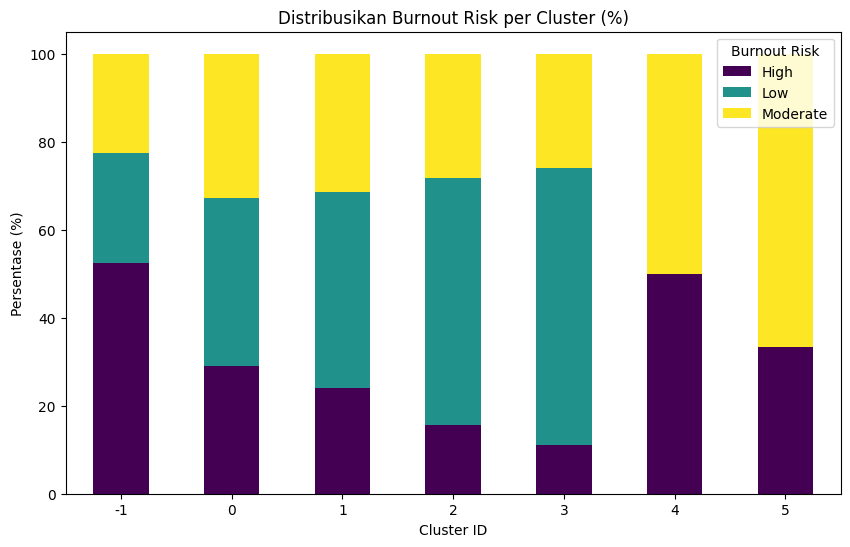

In [ ]:
if 'Burnout_Risk' in df.columns:
    crosstab_risk.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
    plt.title('Distribusikan Burnout Risk per Cluster (%)')
    plt.xlabel('Cluster ID')
    plt.ylabel('Persentase (%)')
    plt.legend(title='Burnout Risk')
    plt.xticks(rotation=0)
    plt.show()

6.4 Ringkasan Model

In [ ]:
# 6.4 Ringkasan Model DBSCAN
n_clusters_ = len(set(clusters_pca)) - (1 if -1 in clusters_pca else 0)
n_noise_ = list(clusters_pca).count(-1)
noise_pct_ = (n_noise_ / len(df)) * 100

print("=" * 50)
print("             RINGKASAN HASIL MODEL DBSCAN           ")
print("=" * 50)
print(f"Total Jumlah Data           : {len(df):,} baris")
print(f"Metrik Jarak                : Euclidean")
print(f"Metode Reduksi Dimensi      : PCA (2 Komponen)")
print(f"Parameter eps               : {db_pca.eps}")
print(f"Parameter min_samples       : {db_pca.min_samples}")
print("-" * 50)
print(f"Jumlah Klaster Terbentuk    : {n_clusters_} klaster")
print(f"Jumlah Data Outlier (Noise) : {n_noise_:,} baris")
print(f"Persentase Noise            : {noise_pct_:.2f}%")
print("=" * 50)

# Menampilkan distribusi anggota per klaster
df_summary = pd.Series(clusters_pca).value_counts().reset_index()
df_summary.columns = ['Cluster ID', 'Jumlah Anggota']
df_summary['Persentase (%)'] = (df_summary['Jumlah Anggota'] / len(df) * 100).round(2)
df_summary['Keterangan'] = df_summary['Cluster ID'].apply(lambda x: 'Noise / Outlier' if x == -1 else f'Cluster {x}')

display(df_summary[['Cluster ID', 'Keterangan', 'Jumlah Anggota', 'Persentase (%)']])

             RINGKASAN HASIL MODEL DBSCAN           
Total Jumlah Data           : 50,000 baris
Metrik Jarak                : Euclidean
Metode Reduksi Dimensi      : PCA (2 Komponen)
Parameter eps               : 0.1
Parameter min_samples       : 4
--------------------------------------------------
Jumlah Klaster Terbentuk    : 6 klaster
Jumlah Data Outlier (Noise) : 40 baris
Persentase Noise            : 0.08%


,Cluster ID,Keterangan,Jumlah Anggota,Persentase (%)
0,2,Cluster 2,17030,34.06
1,1,Cluster 1,16749,33.50
2,3,Cluster 3,8446,16.89
3,0,Cluster 0,7725,15.45
4,-1,Noise / Outlier,40,0.08
5,5,Cluster 5,6,0.01
6,4,Cluster 4,4,0.01
